# Exploratory Data Analysis
The objective is to inspect the data, get general understanding of the datasets, check for patterns, understand what preprocessing should be done before the modeling.

## Some questions we would like to answer here:

What's the distribution of engines lifetime in the train sets - and distribution of last time cycle in test sets?
What's the distribution of Remaining Useful Life in the test sets?
What are wear/degradation patterns?
What are distributions of operational settings?
What's the difference between engines?

### Main EDA takeaways:

there're patterns of increasing/decreasing trends, indicating degradations, in some of FD00{1,3} sensors time series
however, the two other datasets should be sclaled per operational condition - there're 6 op conditions, which can be identified with simple clustering
some sensors time series are constant and are redundant for the modeling
50% of units in all the test sets have smaller last time cycle than train sets minimum lifetime

In [5]:
with open("CMaps/readme.txt", "r") as f:
    content = f.read()

print(content)

Data Set: FD001
Train trjectories: 100
Test trajectories: 100
Conditions: ONE (Sea Level)
Fault Modes: ONE (HPC Degradation)

Data Set: FD002
Train trjectories: 260
Test trajectories: 259
Conditions: SIX 
Fault Modes: ONE (HPC Degradation)

Data Set: FD003
Train trjectories: 100
Test trajectories: 100
Conditions: ONE (Sea Level)
Fault Modes: TWO (HPC Degradation, Fan Degradation)

Data Set: FD004
Train trjectories: 248
Test trajectories: 249
Conditions: SIX 
Fault Modes: TWO (HPC Degradation, Fan Degradation)



Experimental Scenario

Data sets consists of multiple multivariate time series. Each data set is further divided into training and test subsets. Each time series is from a different engine – i.e., the data can be considered to be from a fleet of engines of the same type. Each engine starts with different degrees of initial wear and manufacturing variation which is unknown to the user. This wear and variation is considered normal, i.e., it is not considered a fault condition. Th

In [6]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

%matplotlib inline

In [12]:
DATASET_NAMES = ["FD001", "FD002", "FD003", "FD004"]
TRAIN_DATA_FILES = [("CMaps/train_{}.txt".format(x), x) for x in DATASET_NAMES]
TEST_DATA_FILES = [("CMaps/test_{}.txt".format(x), x) for x in DATASET_NAMES]
TEST_DATA_RUL_FILES = [("CMaps/RUL_{}.txt".format(x), x) for x in DATASET_NAMES]

OP_SETTING_COLUMNS = ["op_setting_{}".format(x) for x in range(1, 4)]
SENSOR_COLUMNS = ["sensor_{}".format(x) for x in range(1, 22)]

In [13]:
def read_data(filename):
    col_names = ["unit", "time_cycles"] + OP_SETTING_COLUMNS + SENSOR_COLUMNS
    return pd.read_csv(filename, sep="\s+", header=None, names=col_names)

In [14]:
train_FD001 = read_data("CMaps/train_FD001.txt")
print("train_FD001.shape = {}".format(train_FD001.shape))
train_FD001.head(2)

train_FD001.shape = (20631, 26)


,unit,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236


In [18]:
train = []
for dataset in TRAIN_DATA_FILES:
    dataset_df = read_data(dataset[0])
    dataset_df["dataset"] = dataset[1]
    train.append(dataset_df)

train = pd.concat(train, ignore_index=True)

print("train.shape = {}".format(train.shape))
train.head(25)

train.shape = (160359, 27)


,unit,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,FD001
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,FD001
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,FD001
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,FD001
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669,FD001
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774,FD001
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106,FD001
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066,FD001
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694,FD001


In [16]:
test = []
for dataset in TEST_DATA_FILES:
    dataset_df = read_data(dataset[0])
    dataset_df["dataset"] = dataset[1]
    test.append(dataset_df)

test = pd.concat(test, ignore_index=True)

print("test.shape = {}".format(test.shape))

test.shape = (104897, 27)


In [17]:
test_rul = []
for dataset in TEST_DATA_RUL_FILES:
    dataset_df = pd.read_csv(dataset[0], header=None, names=["rul"])
    dataset_df["dataset"] = dataset[1]
    test_rul.append(dataset_df)

test_rul = pd.concat(test_rul, ignore_index=True)
test_rul["unit"] = test[["unit", "dataset"]].drop_duplicates()["unit"].values

print(f"test_rul.shape = {test_rul.shape}")

test_rul.head(25)

test_rul.shape = (707, 3)


,rul,dataset,unit
0,112,FD001,1
1,98,FD001,2
2,69,FD001,3
3,82,FD001,4
4,91,FD001,5
5,93,FD001,6
6,91,FD001,7
7,95,FD001,8
8,111,FD001,9
9,96,FD001,10


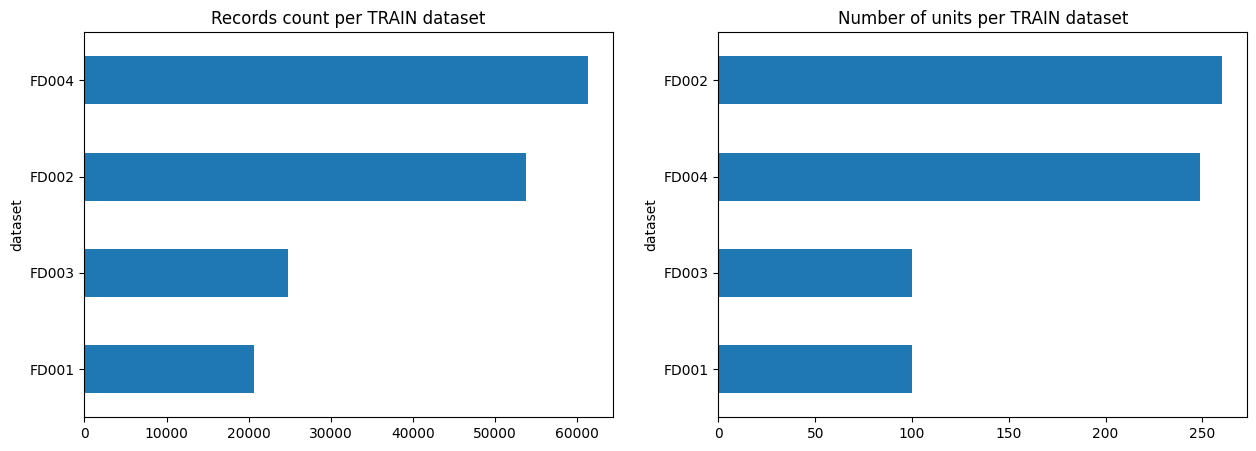

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
train.groupby("dataset").size().sort_values().plot.barh(ax=ax[0])
ax[0].set_title("Records count per TRAIN dataset")

train.groupby("dataset")["unit"].max().sort_values().plot.barh(ax=ax[1])
ax[1].set_title("Number of units per TRAIN dataset")

fig.show()